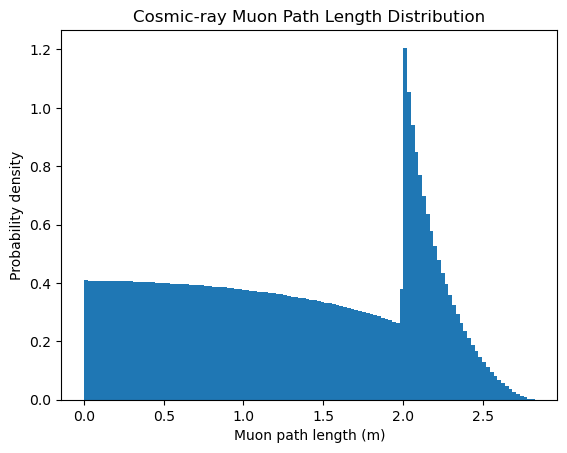

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Detector geometry
# ----------------------------
R = 1.0
H = 2.0
a = 1.3
N = 100_000_000  # easily scalable to 10M+

# ----------------------------
# Entry points (top surface)
# ----------------------------
r = R * np.sqrt(np.random.rand(N))
phi = 2*np.pi*np.random.rand(N)

x0 = r*np.cos(phi)
y0 = r*np.sin(phi)
z0 = np.full(N, H/2)

# ----------------------------
# Cosmic-ray angular distribution
# approx cos^2(theta)
# ----------------------------
theta = np.arccos(np.random.rand(N))
phi_dir = 2*np.pi*np.random.rand(N)

accept = np.random.rand(N) < np.power(np.cos(theta),a)
theta = theta[accept]
phi_dir = phi_dir[accept]

x0 = x0[accept]
y0 = y0[accept]
z0 = z0[accept]

# direction vectors
vx = np.sin(theta)*np.cos(phi_dir)
vy = np.sin(theta)*np.sin(phi_dir)
vz = -np.cos(theta)

# ----------------------------
# Cylinder wall intersection
# ----------------------------
a = vx**2 + vy**2
b = 2*(x0*vx + y0*vy)
c = x0**2 + y0**2 - R**2

disc = b**2 - 4*a*c
disc[disc < 0] = np.nan

t1 = (-b + np.sqrt(disc))/(2*a)
t2 = (-b - np.sqrt(disc))/(2*a)

# keep forward solutions
#t_side = np.where((t1 > 0) & (t1 < t2), t1, t2)
t_side = np.where((t1 > 0), t1, t2)

# ----------------------------
# Bottom cap intersection
# ----------------------------
t_bottom = (-H/2 - z0)/vz
t_bottom[t_bottom <= 0] = np.nan

# ----------------------------
# Choose first exit
# ----------------------------
t_exit = np.nanmin(np.vstack([t_side, t_bottom]), axis=0)

# path lengths

vnorm = np.sqrt(vx**2 + vy**2 + vz**2)

lengths = t_exit * vnorm

# remove NaNs
lengths = lengths[np.isfinite(lengths)]

# ----------------------------
# Histogram
# ----------------------------
plt.hist(lengths, bins=120, density=True)
plt.yscale('linear')
plt.xlabel("Muon path length (m)")
plt.ylabel("Probability density")
plt.title("Cosmic-ray Muon Path Length Distribution")
plt.show()